# Behavioral clustering + Marketplace intelligence (1010 / 1020)

Notebook bổ sung cho `eda_category_1010_1020_performance.ipynb`, áp dụng **mapping UI đúng**:

| category | UI |
|----------|----|
| **1010** | Căn hộ / Chung cư |
| **1020** | Nhà ở |

## Mục tiêu business (datathon)

**Maximize contact rate** + **marketplace health** → không chỉ recommendation, mà:

- Matching quality (user intent ↔ listing attractiveness)
- Behavior understanding (intent clusters)
- Supply–demand dynamics (seller quality, cold inventory)

## Ba thực thể + pipeline

```
fact_user_events  ──►  sessionization + aggregates
dim_listing       ──►  static / form features (theo eda_role)
fact_listing_snapshot ─ exposure (views_24h) + listing_age_days

        ┌─────────────┬─────────────┬─────────────┐
        ▼             ▼             ▼             ▼
   User intent   Listing perf   Seller health  Session journey
        │             │             │             │
        └─────────────┴──────┬──────┴─────────────┘
                             ▼
              features → scale → UMAP → HDBSCAN → interpret
```

## 6 hướng phân cụm (ưu tiên triển khai)

| # | Hướng | Grain | Ví dụ cluster | Notebook section |
|---|--------|-------|---------------|------------------|
| 1 | **User intent** | `user_id` × `category` | Urgent buyers, window shoppers, focused renters | §3 |
| 2 | **Listing attractiveness** | `item_id` | High-conversion gems, clickbait, cold inventory | §4 |
| 3 | **Seller / agent** | `seller_id` | Pro brokers, casual owners, spammy posters | §5 |
| 4 | **Session journey** | `session_id` | Deep compare → contact vs bounce scroll | §6 |
| 5 | **Time-series lifecycle** | `item_id` × `date` | Fast burn vs slow burn (DTW / shape — phase 2) | §7 roadmap |
| 6 | **Marketplace health** | `item_id` | High quality, underexposed | §8 |

**Giai đoạn notebook này:** Event engineering → entity feature tables → **UMAP + HDBSCAN** MVP trên user / listing / seller (sample RAM-friendly).

**Giai đoạn tiếp:** embedding (co-view sequences), tslearn lifecycle, fairness constraints cho recsys.

**Chạy:** Run All từ Setup (sau §1 có `dim_cat` + `listing_snap`).

**Cài package** (kernel `env` trong project):

```bash
cd Datathon_Data && ./env/bin/pip install -r requirements-eda.txt
```

**Export:** `outputs/eda_category_1010_1020/clustering/`

In [1]:
%matplotlib inline

from __future__ import annotations

import json
import warnings
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

try:
    import hdbscan
    import umap

    HAS_HDBSCAN = True
    HAS_UMAP = True
except ImportError:
    HAS_HDBSCAN = False
    HAS_UMAP = False
    from sklearn.cluster import Birch

DATA_ROOT = Path.cwd().resolve()
for name in ("dim_listing", "fact_user_events", "fact_listing_snapshot"):
    if not (DATA_ROOT / name).exists():
        raise FileNotFoundError(f"Thiếu `{name}` trong {DATA_ROOT}")

OUT_DIR = DATA_ROOT / "outputs" / "eda_category_1010_1020" / "clustering"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DIM_GLOB = str(DATA_ROOT / "dim_listing" / "*.parquet")
EVENTS_GLOB = str(DATA_ROOT / "fact_user_events" / "*.parquet")
SNAP_GLOB = str(DATA_ROOT / "fact_listing_snapshot" / "*.parquet")

DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2
CATS = (1010, 1020)
CAT_SQL = "1010, 1020"
UI_LABELS = {1010: "Căn hộ / Chung cư", 1020: "Nhà ở"}

POSITIVE_TYPES = (
    "view_phone", "contact_chat", "other_interaction",
    "contact_zalo", "contact_sms",
)
POS_SQL = ", ".join(repr(x) for x in POSITIVE_TYPES)

# RAM: sample events cho clustering (None = full — chỉ khi đủ RAM)
CLUSTER_EVENT_SAMPLE_FRAC: float | None = 0.06
USER_MIN_EVENTS = 8
LISTING_MIN_PAGEVIEWS = 5
SELLER_MIN_LISTINGS = 3
MAX_ROWS_CLUSTER = 40_000
HDBSCAN_MIN_CLUSTER_SIZE = 80

con = duckdb.connect(":memory:")
con.execute(f"PRAGMA memory_limit='{DUCKDB_MEMORY_LIMIT}'")
con.execute(f"PRAGMA threads={DUCKDB_THREADS}")


def sample_clause(frac: float | None) -> str:
    if frac is None:
        return ""
    if not (0 < float(frac) < 1):
        raise ValueError("sample frac phải trong (0,1)")
    return f"AND random() < {float(frac)}"


def entropy_from_counts(counts: np.ndarray) -> float:
    counts = counts[counts > 0].astype(float)
    if counts.size == 0:
        return 0.0
    p = counts / counts.sum()
    return float(-(p * np.log(p)).sum())


def behavioral_cluster(
    df: pd.DataFrame,
    feature_cols: list[str],
    id_col: str,
    title: str,
) -> pd.DataFrame:
    """Scale → UMAP (2D) → HDBSCAN; fallback PCA + Birch."""
    work = df.dropna(subset=feature_cols, how="all").copy()
    if len(work) > MAX_ROWS_CLUSTER:
        work = work.sample(MAX_ROWS_CLUSTER, random_state=42)
    X = work[feature_cols].astype(float).fillna(0.0).values
    Xs = RobustScaler().fit_transform(X)

    if HAS_UMAP and len(work) >= 500:
        reducer = umap.UMAP(n_neighbors=25, min_dist=0.15, metric="euclidean", random_state=42)
        emb2 = reducer.fit_transform(Xs)
    else:
        emb2 = PCA(n_components=2, random_state=42).fit_transform(Xs)

    if HAS_HDBSCAN:
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
            min_samples=10,
            metric="euclidean",
        )
        labels = clusterer.fit_predict(Xs)
    else:
        birch = Birch(n_clusters=None, threshold=0.5)
        labels = birch.fit_predict(Xs)

    out = work[[id_col] + [c for c in work.columns if c in ("category", "ad_type")]].copy()
    out["cluster_id"] = labels
    out["umap_x"] = emb2[:, 0]
    out["umap_y"] = emb2[:, 1]
    for c in feature_cols:
        out[c] = work[c].values

    prof = (
        out.groupby("cluster_id", dropna=False)[feature_cols]
        .mean()
        .round(4)
        .reset_index()
    )
    prof["n"] = out.groupby("cluster_id").size().values
    prof.to_csv(OUT_DIR / f"profile_{title}.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(out["umap_x"], out["umap_y"], c=out["cluster_id"], cmap="tab20", s=8, alpha=0.55)
    ax.set_title(f"UMAP/PCA + cluster — {title}")
    plt.colorbar(sc, ax=ax, label="cluster_id")
    plt.tight_layout()
    fig.savefig(OUT_DIR / f"scatter_{title}.png", dpi=120, bbox_inches="tight")
    plt.show()
    return out


print("OUT_DIR =", OUT_DIR)
print("CLUSTER_EVENT_SAMPLE_FRAC =", CLUSTER_EVENT_SAMPLE_FRAC)
print("HDBSCAN/UMAP available:", HAS_HDBSCAN, HAS_UMAP)

OUT_DIR = /Users/dothinh_3112/Downloads/Datathon_Data/outputs/eda_category_1010_1020/clustering
CLUSTER_EVENT_SAMPLE_FRAC = 0.06
HDBSCAN/UMAP available: True True


## §1 — Event engineering (sessionization + flags)

Một dòng event được enrich:
- `is_positive`, `is_pageview`, `is_contact`
- `hour`, `is_weekend`, `is_night` (22h–6h)
- join `dim_listing` → `district_name`, `ad_type`, static listing attrs

In [2]:
print("Materializing events_enriched (1010+1020) …")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE events_enriched AS
SELECT
    e.user_id,
    e.session_id,
    CAST(e.item_id AS VARCHAR) AS item_id,
    e.category,
    e.event_type,
    e.event_ts,
    e.date,
    e.device,
    e.position,
    e.dwell_time_sec,
    e.query,
    e.is_login,
    CASE WHEN e.event_type IN ({POS_SQL}) THEN 1 ELSE 0 END AS is_positive,
    CASE WHEN e.event_type = 'pageview' THEN 1 ELSE 0 END AS is_pageview,
    CASE WHEN e.event_type IN ({POS_SQL}) THEN 1 ELSE 0 END AS is_contact,
    CASE WHEN e.query IS NOT NULL AND TRIM(CAST(e.query AS VARCHAR)) != '' THEN 1 ELSE 0 END AS is_search,
    EXTRACT('hour' FROM e.event_ts) AS hour,
    CASE WHEN EXTRACT('dow' FROM e.event_ts) IN (0, 6) THEN 1 ELSE 0 END AS is_weekend,
    CASE WHEN EXTRACT('hour' FROM e.event_ts) >= 22 OR EXTRACT('hour' FROM e.event_ts) < 6 THEN 1 ELSE 0 END AS is_night,
    d.ad_type,
    d.district_name,
    d.city_name,
    d.area_sqm,
    d.bedrooms,
    d.seller_id,
    d.seller_type,
    d.price_bucket
FROM read_parquet('{EVENTS_GLOB}') e
INNER JOIN read_parquet('{DIM_GLOB}') d ON CAST(e.item_id AS VARCHAR) = CAST(d.item_id AS VARCHAR)
WHERE e.category IN ({CAT_SQL})
  {sample_clause(CLUSTER_EVENT_SAMPLE_FRAC)}
""")
ev_stats = con.execute("""
SELECT COUNT(*) AS n_events,
       COUNT(DISTINCT user_id) AS n_users,
       COUNT(DISTINCT session_id) AS n_sessions,
       COUNT(DISTINCT item_id) AS n_listings
FROM events_enriched
""").df()
display(ev_stats)
ev_stats.to_csv(OUT_DIR / "00_events_enriched_stats.csv", index=False)

print("Materializing dim_cat + listing_snap …")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE dim_cat AS
SELECT
    CAST(item_id AS VARCHAR) AS item_id,
    category,
    ad_type,
    area_sqm,
    bedrooms,
    district_name,
    city_name,
    CAST(seller_id AS VARCHAR) AS seller_id,
    seller_type,
    price_bucket
FROM read_parquet('{DIM_GLOB}')
WHERE category IN ({CAT_SQL})
""")
con.execute(f"""
CREATE OR REPLACE TEMP TABLE listing_snap AS
SELECT
    CAST(s.item_id AS VARCHAR) AS item_id,
    MEDIAN(s.views_24h) AS median_views_24h,
    MEDIAN(s.contacts_24h) AS median_contacts_24h,
    MEDIAN(s.listing_age_days) AS median_age_days
FROM read_parquet('{SNAP_GLOB}') s
INNER JOIN dim_cat d ON CAST(s.item_id AS VARCHAR) = d.item_id
GROUP BY CAST(s.item_id AS VARCHAR)
""")
print("dim_cat rows:", con.execute("SELECT COUNT(*) FROM dim_cat").fetchone()[0])
print("listing_snap rows:", con.execute("SELECT COUNT(*) FROM listing_snap").fetchone()[0])

Materializing events_enriched (1010+1020) …


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n_events,n_users,n_sessions,n_listings
0,5803709,1075975,2274862,371046


Materializing dim_cat + listing_snap …


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

dim_cat rows: 2119687
listing_snap rows: 460935


## §2 — Entity feature tables (1 row = 1 entity)

Export CSV dùng cho ML / clustering offline.

In [3]:
# --- 2a User intent features (user_id × category) ---
user_feats = con.execute(f"""
SELECT
    user_id,
    category,
    COUNT(*)::BIGINT AS n_events,
    COUNT(DISTINCT session_id)::BIGINT AS n_sessions,
    COUNT(DISTINCT item_id)::BIGINT AS n_listings_touched,
    COUNT(DISTINCT district_name)::BIGINT AS n_districts,
    SUM(is_pageview)::BIGINT AS n_pageviews,
    SUM(is_contact)::BIGINT AS n_contacts,
    SUM(is_search)::BIGINT AS n_search_events,
    ROUND(100.0 * SUM(is_contact) / NULLIF(SUM(is_pageview), 0), 4) AS contact_rate_pct,
    ROUND(100.0 * AVG(is_weekend), 2) AS pct_weekend,
    ROUND(100.0 * AVG(is_night), 2) AS pct_night,
    ROUND(AVG(CASE WHEN is_pageview = 1 THEN dwell_time_sec END), 2) AS avg_dwell_sec,
    ROUND(AVG(CASE WHEN is_pageview = 1 THEN position END), 2) AS avg_feed_position,
    ROUND(AVG(area_sqm), 2) AS avg_area_viewed,
    ROUND(AVG(bedrooms), 2) AS avg_bedrooms_viewed,
    ROUND(100.0 * AVG(CASE WHEN ad_type = 'let' THEN 1.0 ELSE 0.0 END), 2) AS pct_let_listings_viewed
FROM events_enriched
WHERE user_id IS NOT NULL
GROUP BY user_id, category
HAVING COUNT(*) >= {USER_MIN_EVENTS}
""").df()
user_feats["ui_label"] = user_feats["category"].map(UI_LABELS)
user_feats.to_csv(OUT_DIR / "01_user_intent_features.csv", index=False)
display(Markdown(f"**User features:** {len(user_feats):,} rows"))
display(user_feats.describe().T.head(12))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**User features:** 156,822 rows

,count,mean,std,min,25%,50%,75%,max
category,156822.0,1017.094987,4.539952,1010.0,1010.0000,1020.00,1020.0000,1020.0
n_events,156822.0,22.540766,32.892242,8.0,10.0000,13.00,22.0000,1470.0
n_sessions,156822.0,8.462550,14.127102,1.0,2.0000,5.00,9.0000,1214.0
n_listings_touched,156822.0,16.524557,23.722887,1.0,7.0000,10.00,17.0000,1163.0
n_districts,156822.0,3.438191,3.015844,1.0,1.0000,3.00,4.0000,82.0
n_pageviews,156822.0,8.396290,13.583085,0.0,2.0000,5.00,9.0000,739.0
n_contacts,156822.0,14.144476,23.599155,0.0,6.0000,9.00,14.0000,1000.0
n_search_events,156822.0,0.351787,1.685224,0.0,0.0000,0.00,0.0000,143.0
contact_rate_pct,144534.0,344.724518,430.256005,0.0,63.1579,180.00,450.0000,14300.0
pct_weekend,156822.0,25.591516,29.741915,0.0,0.0000,16.06,40.0000,100.0


In [4]:
# district entropy (Python) per user×category
dist_counts = con.execute("""
SELECT user_id, category, district_name, COUNT(*) AS c
FROM events_enriched
WHERE district_name IS NOT NULL AND user_id IS NOT NULL
GROUP BY 1, 2, 3
""").df()
ent = (
    dist_counts.groupby(["user_id", "category"])["c"]
    .apply(lambda s: entropy_from_counts(s.values))
    .reset_index(name="district_entropy")
)
user_feats = user_feats.merge(ent, on=["user_id", "category"], how="left")
user_feats["district_entropy"] = user_feats["district_entropy"].fillna(0)
user_feats.to_csv(OUT_DIR / "01_user_intent_features.csv", index=False)

In [5]:
# --- 2b Listing behavioral attractiveness ---
# dim_cat + listing_snap: tạo ở §1 (tránh ambiguous item_id khi join snapshot)
listing_feats = con.execute(f"""
WITH ev AS (
    SELECT
        item_id,
        category,
        SUM(is_pageview) AS n_pageviews,
        SUM(is_contact) AS n_contacts,
        COUNT(DISTINCT user_id) AS n_unique_users,
        ROUND(AVG(CASE WHEN is_pageview = 1 THEN dwell_time_sec END), 2) AS avg_dwell_sec,
        ROUND(AVG(CASE WHEN is_pageview = 1 THEN position END), 2) AS avg_position,
        ROUND(100.0 * SUM(is_contact) / NULLIF(SUM(is_pageview), 0), 4) AS contact_rate_pct
    FROM events_enriched
    GROUP BY item_id, category
    HAVING SUM(is_pageview) >= {LISTING_MIN_PAGEVIEWS}
),
repeat AS (
    SELECT item_id,
           COUNT(*) FILTER (WHERE pv_cnt > 1) AS repeat_viewers,
           COUNT(*) AS viewers
    FROM (
        SELECT item_id, user_id, SUM(is_pageview) AS pv_cnt
        FROM events_enriched
        WHERE user_id IS NOT NULL
        GROUP BY item_id, user_id
    ) t
    GROUP BY item_id
)
SELECT
    e.item_id,
    e.category,
    d.ad_type,
    d.area_sqm,
    d.bedrooms,
    d.district_name,
    d.seller_type,
    e.n_pageviews,
    e.n_contacts,
    e.n_unique_users,
    e.contact_rate_pct,
    e.avg_dwell_sec,
    e.avg_position,
    ROUND(100.0 * r.repeat_viewers / NULLIF(r.viewers, 0), 2) AS repeat_viewer_pct,
    s.median_views_24h,
    s.median_contacts_24h,
    s.median_age_days
FROM ev e
INNER JOIN dim_cat d ON e.item_id = d.item_id
LEFT JOIN repeat r ON e.item_id = r.item_id
LEFT JOIN listing_snap s ON e.item_id = s.item_id
""").df()
listing_feats["ui_label"] = listing_feats["category"].map(UI_LABELS)
listing_feats.to_csv(OUT_DIR / "02_listing_behavior_features.csv", index=False)
display(Markdown(f"**Listing features:** {len(listing_feats):,} rows"))
display(listing_feats.head(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Listing features:** 133,522 rows

,item_id,category,ad_type,area_sqm,bedrooms,district_name,seller_type,n_pageviews,n_contacts,n_unique_users,contact_rate_pct,avg_dwell_sec,avg_position,repeat_viewer_pct,median_views_24h,median_contacts_24h,median_age_days,ui_label
0,400be2ddf22f84d8caed4d9a90fe787d6a055c15ffce65...,1020,sell,10.0,2,Quận Bình Thạnh,private,25.0,21.0,37,84.0000,47364.09,45.29,2.70,8.0,1.0,16.5,Nhà ở
1,2f2644389a23294594bb2f3d505d26e233c72e3679e13c...,1020,let,12.0,1,Quận Tân Phú,private,12.0,26.0,24,216.6667,57095.64,6.36,0.00,1.0,14.0,21.0,Nhà ở
2,5f219f54bdb62fc40704d6b1c84782e6497ecfe73298df...,1020,let,12.0,1,Thành phố Thủ Đức,agent,43.0,68.0,73,158.1395,27583.59,17.38,2.74,74.0,3.0,3.0,Nhà ở


In [6]:
# --- 2c Seller / agent marketplace health ---
seller_feats = con.execute(f"""
WITH listing_perf AS (
    SELECT
        CAST(d.seller_id AS VARCHAR) AS seller_id,
        d.category,
        d.seller_type,
        COUNT(DISTINCT d.item_id) AS n_listings,
        SUM(COALESCE(e.n_pageviews, 0)) AS total_pageviews,
        SUM(COALESCE(e.n_contacts, 0)) AS total_contacts,
        ROUND(AVG(COALESCE(e.contact_rate_pct, 0)), 4) AS avg_listing_contact_rate
    FROM dim_cat d
    LEFT JOIN (
        SELECT item_id, SUM(is_pageview) AS n_pageviews, SUM(is_contact) AS n_contacts,
               ROUND(100.0 * SUM(is_contact) / NULLIF(SUM(is_pageview), 0), 4) AS contact_rate_pct
        FROM events_enriched GROUP BY item_id
    ) e ON d.item_id = e.item_id
    WHERE d.seller_id IS NOT NULL
    GROUP BY 1, 2, 3
    HAVING COUNT(DISTINCT d.item_id) >= {SELLER_MIN_LISTINGS}
)
SELECT *,
    ROUND(total_contacts * 1.0 / NULLIF(n_listings, 0), 2) AS contacts_per_listing,
    ROUND(total_pageviews * 1.0 / NULLIF(n_listings, 0), 2) AS pageviews_per_listing
FROM listing_perf
""").df()
seller_feats.to_csv(OUT_DIR / "03_seller_features.csv", index=False)
display(Markdown(f"**Seller features:** {len(seller_feats):,} rows"))

**Seller features:** 64,145 rows

In [7]:
# --- 2d Session journey shape ---
session_feats = con.execute("""
SELECT
    session_id,
    category,
    MAX(device) AS device,
    COUNT(*)::BIGINT AS n_events,
    COUNT(DISTINCT item_id)::BIGINT AS n_items,
    MAX(is_search) AS has_search,
    MAX(is_contact) AS has_contact,
    SUM(is_pageview)::BIGINT AS n_pageviews,
    ROUND(MAX(dwell_time_sec), 1) AS max_dwell_sec,
    ROUND(AVG(CASE WHEN is_pageview = 1 THEN dwell_time_sec END), 2) AS avg_dwell_sec,
    MIN(event_ts) AS session_start,
    MAX(event_ts) AS session_end,
    EXTRACT('epoch' FROM MAX(event_ts) - MIN(event_ts)) / 60.0 AS duration_min
FROM events_enriched
WHERE session_id IS NOT NULL
GROUP BY session_id, category
HAVING COUNT(*) >= 3
""").df()
def _bool_flag(series: pd.Series) -> pd.Series:
    return series.fillna(False).astype("int8")

session_feats["deep_compare"] = _bool_flag(
    (session_feats["n_items"] >= 3)
    & (session_feats["max_dwell_sec"].fillna(0) >= 60)
)
session_feats["bounce_like"] = _bool_flag(
    (session_feats["n_pageviews"] >= 2)
    & (session_feats["has_contact"].fillna(0) == 0)
    & (session_feats["avg_dwell_sec"].fillna(0) < 15)
)
session_feats.to_csv(OUT_DIR / "04_session_journey_features.csv", index=False)
display(Markdown(f"**Session features:** {len(session_feats):,} rows"))
display(session_feats[["has_contact", "deep_compare", "bounce_like"]].mean().to_frame("rate"))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

**Session features:** 671,423 rows

,rate
has_contact,0.908265
deep_compare,0.572153
bounce_like,0.000018


## §3 — User intent clustering (HDBSCAN)

Feature behavioral (không demographic). Chạy **riêng từng category** vì intent thuê căn hộ ≠ mua nhà.

/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


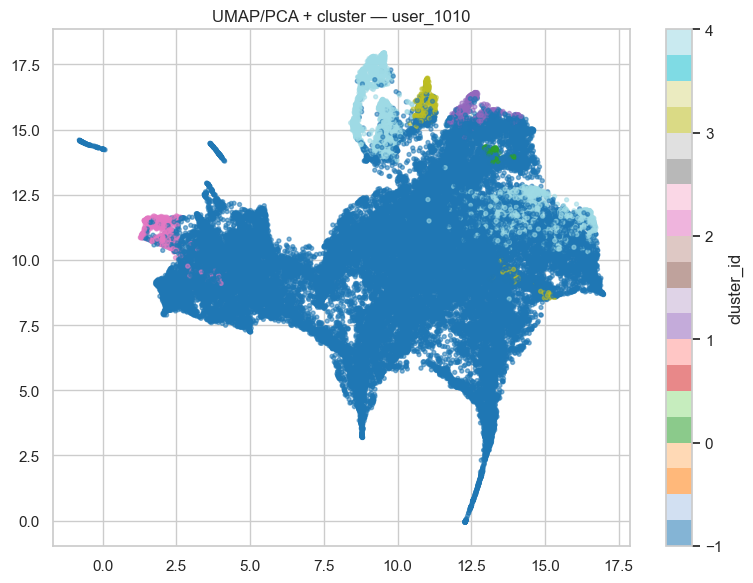

/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


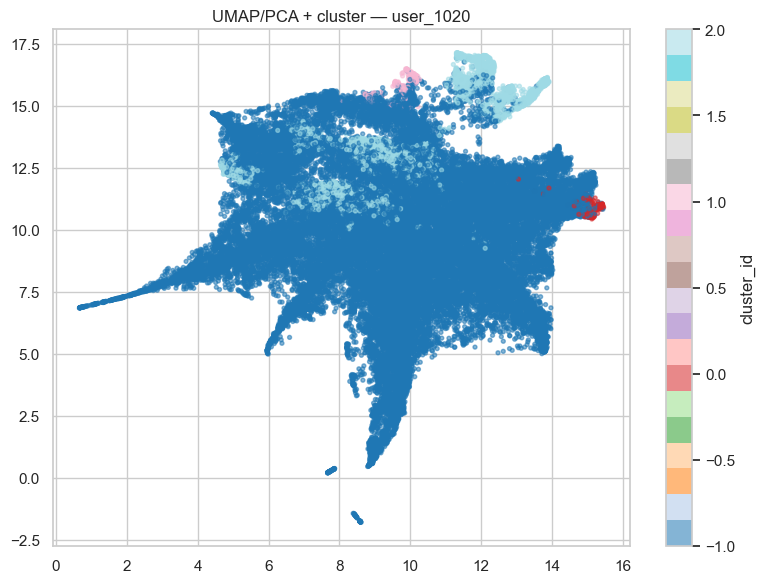

,category,cluster_id,n,contact_rate_pct,district_entropy,pct_night,suggested_label
0,1010,-1,35369,384.758804,0.845479,23.054454,Typical browser
5,1010,4,3184,428.537140,0.401607,0.829607,Typical browser
3,1010,2,506,154.025162,0.383790,0.246403,Typical browser
4,1010,3,467,455.215775,0.279948,0.286039,Typical browser
2,1010,1,348,376.485558,0.335835,99.021121,Night-active searcher
1,1010,0,126,422.123844,0.286030,98.652143,Night-active searcher
6,1020,-1,35894,328.763637,0.768229,18.464135,Typical browser
9,1020,2,3595,335.817076,0.336215,0.339955,Typical browser
8,1020,1,338,260.884715,0.161460,0.102604,Typical browser
7,1020,0,173,191.793928,0.283455,98.202312,Night-active searcher


In [8]:
USER_CLUSTER_COLS = [
    "n_sessions", "n_listings_touched", "n_districts", "district_entropy",
    "contact_rate_pct", "pct_weekend", "pct_night", "avg_dwell_sec",
    "avg_feed_position", "avg_area_viewed", "avg_bedrooms_viewed", "pct_let_listings_viewed",
]

INTENT_LABEL_RULES = {
    "high_contact": ("contact_rate_pct", 5.0, "gt"),
    "low_contact": ("contact_rate_pct", 1.5, "lt"),
    "broad_explorer": ("district_entropy", 1.5, "gt"),
    "focused": ("n_districts", 2, "le"),
    "night_active": ("pct_night", 35, "gt"),
}


def suggest_intent_name(row: pd.Series) -> str:
    if row.get("contact_rate_pct", 0) >= 8 and row.get("n_contacts", 0) >= 2:
        return "High-intent / urgent"
    if row.get("contact_rate_pct", 0) < 1 and row.get("n_pageviews", 0) >= 15:
        return "Window shopper"
    if row.get("district_entropy", 0) >= 1.8:
        return "Geo explorer"
    if row.get("pct_night", 0) >= 40:
        return "Night-active searcher"
    if row.get("avg_area_viewed", 0) >= 120:
        return "Large-space seeker"
    return "Typical browser"


user_cluster_parts = []
for cat in CATS:
    sub = user_feats[user_feats["category"] == cat]
    if len(sub) < HDBSCAN_MIN_CLUSTER_SIZE * 2:
        print(f"Skip user cluster cat={cat}, n={len(sub)}")
        continue
    tagged = behavioral_cluster(sub, USER_CLUSTER_COLS, "user_id", f"user_{cat}")
    tagged["category"] = cat
    user_cluster_parts.append(tagged)

if user_cluster_parts:
    user_clustered = pd.concat(user_cluster_parts, ignore_index=True)
    prof = user_clustered.groupby(["category", "cluster_id"], as_index=False).agg(
        n=("user_id", "count"),
        contact_rate_pct=("contact_rate_pct", "mean"),
        district_entropy=("district_entropy", "mean"),
        pct_night=("pct_night", "mean"),
    )
    prof["suggested_label"] = prof.apply(suggest_intent_name, axis=1)
    display(prof.sort_values(["category", "n"], ascending=[True, False]))
    user_clustered.to_csv(OUT_DIR / "10_user_clusters.csv", index=False)
    prof.to_csv(OUT_DIR / "10_user_cluster_profiles.csv", index=False)

## §4 — Listing attractiveness clustering

/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


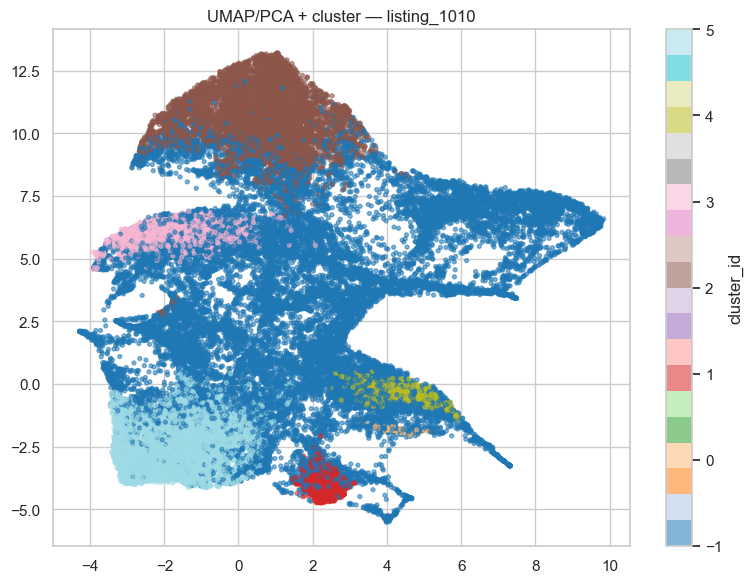

/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


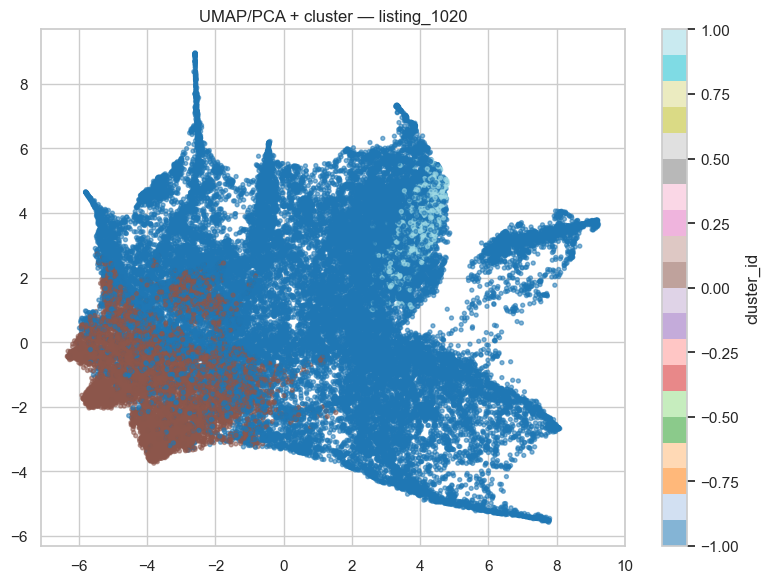

,category,cluster_id,n,contact_rate_pct,n_pageviews,median_age_days,suggested_label
0,1010,-1,21910,184.860125,16.079644,58.389320,Evergreen average
3,1010,2,6750,139.773921,7.451704,15.246889,Evergreen average
6,1010,5,5068,146.765421,7.399763,16.687648,Evergreen average
4,1010,3,1780,115.406196,9.387079,13.139045,Evergreen average
2,1010,1,900,141.119669,6.778889,18.096111,Evergreen average
5,1010,4,856,127.402198,9.081776,14.924065,Evergreen average
1,1010,0,98,111.603528,8.132653,14.688776,Evergreen average
7,1020,-1,30881,158.141338,15.709206,32.709482,Evergreen average
8,1020,0,8145,121.757348,7.199386,14.510006,Evergreen average
9,1020,1,974,105.430788,9.050308,13.679158,Evergreen average


In [9]:
LISTING_CLUSTER_COLS = [
    "n_pageviews", "n_contacts", "n_unique_users", "contact_rate_pct",
    "avg_dwell_sec", "avg_position", "repeat_viewer_pct",
    "median_views_24h", "median_age_days", "area_sqm", "bedrooms",
]


def suggest_listing_name(row: pd.Series) -> str:
    cr = row.get("contact_rate_pct", 0) or 0
    pv = row.get("n_pageviews", 0) or 0
    age = row.get("median_age_days", 999) or 999
    if cr >= 25 and pv >= 20:
        return "High-conversion gem"
    if pv >= 50 and cr < 3:
        return "Clickbait / high view low contact"
    if age <= 7 and cr >= 10:
        return "Fresh fast-moving"
    if age >= 60 and pv < 15:
        return "Cold inventory"
    return "Evergreen average"


listing_cluster_parts = []
for cat in CATS:
    sub = listing_feats[listing_feats["category"] == cat].copy()
    tagged = behavioral_cluster(sub, LISTING_CLUSTER_COLS, "item_id", f"listing_{cat}")
    tagged["category"] = cat
    listing_cluster_parts.append(tagged)

listing_clustered = pd.concat(listing_cluster_parts, ignore_index=True)
lprof = listing_clustered.groupby(["category", "cluster_id"], as_index=False).agg(
    n=("item_id", "count"),
    contact_rate_pct=("contact_rate_pct", "mean"),
    n_pageviews=("n_pageviews", "mean"),
    median_age_days=("median_age_days", "mean"),
)
lprof["suggested_label"] = lprof.apply(suggest_listing_name, axis=1)
display(lprof.sort_values(["category", "n"], ascending=[True, False]).head(20))
listing_clustered.to_csv(OUT_DIR / "11_listing_clusters.csv", index=False)
lprof.to_csv(OUT_DIR / "11_listing_cluster_profiles.csv", index=False)

## §5 — Seller / agent clustering

/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


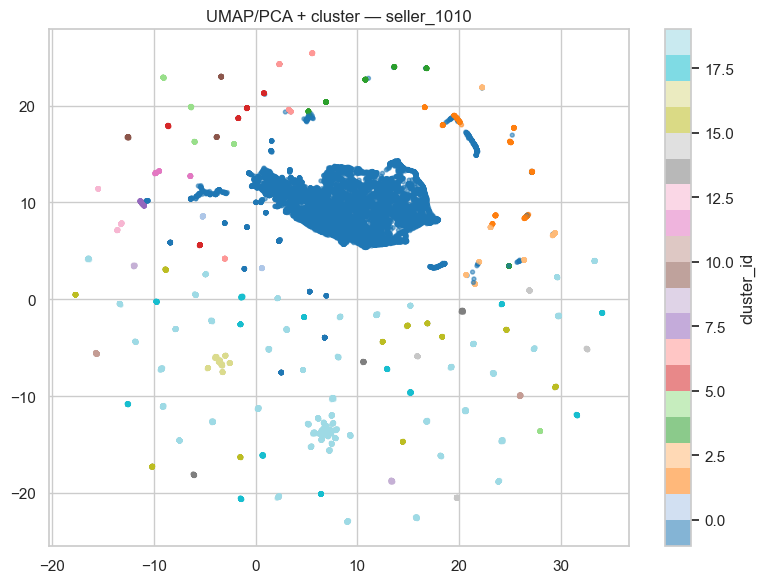

/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


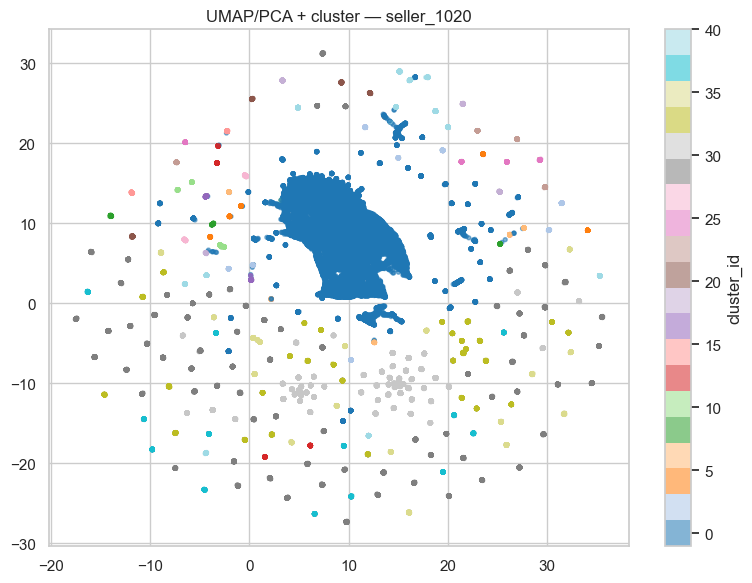

In [10]:
SELLER_CLUSTER_COLS = [
    "n_listings", "total_pageviews", "total_contacts",
    "contacts_per_listing", "pageviews_per_listing", "avg_listing_contact_rate",
]

seller_cluster_parts = []
for cat in CATS:
    sub = seller_feats[seller_feats["category"] == cat]
    if len(sub) < HDBSCAN_MIN_CLUSTER_SIZE * 2:
        continue
    tagged = behavioral_cluster(sub, SELLER_CLUSTER_COLS, "seller_id", f"seller_{cat}")
    tagged["category"] = cat
    seller_cluster_parts.append(tagged)

if seller_cluster_parts:
    seller_clustered = pd.concat(seller_cluster_parts, ignore_index=True)
    seller_clustered.to_csv(OUT_DIR / "12_seller_clusters.csv", index=False)

## §6 — Session journey clustering

/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


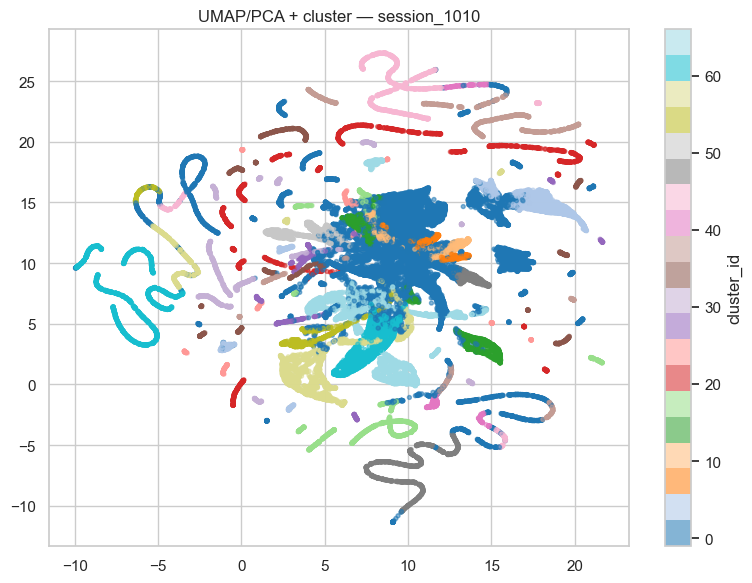

/Users/dothinh_3112/Downloads/Datathon_Data/env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


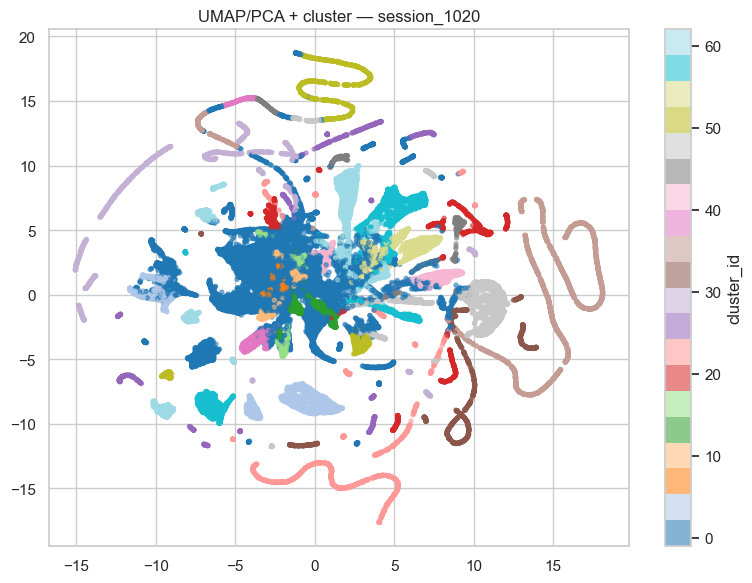

In [11]:
SESSION_CLUSTER_COLS = [
    "n_events", "n_items", "n_pageviews", "duration_min",
    "max_dwell_sec", "avg_dwell_sec", "has_search", "has_contact",
]

session_cluster_parts = []
for cat in CATS:
    sub = session_feats[session_feats["category"] == cat]
    if len(sub) < HDBSCAN_MIN_CLUSTER_SIZE * 3:
        continue
    tagged = behavioral_cluster(sub, SESSION_CLUSTER_COLS, "session_id", f"session_{cat}")
    tagged["category"] = cat
    session_cluster_parts.append(tagged)

if session_cluster_parts:
    session_clustered = pd.concat(session_cluster_parts, ignore_index=True)
    session_clustered.to_csv(OUT_DIR / "13_session_clusters.csv", index=False)

## §7 — Marketplace health: underexposed high-quality listings

Ý tưởng: **contact_rate cao** nhưng **exposure thấp** (median `views_24h` hoặc `n_pageviews`) → ưu tiên đẩy feed / diversity.

,category,health_segment,n
0,1010,high_quality_underexposed,2359
1,1010,normal,32860
2,1010,oversaturated_low_conversion,2143
3,1020,high_quality_underexposed,6122
4,1020,normal,85722
5,1020,oversaturated_low_conversion,4316


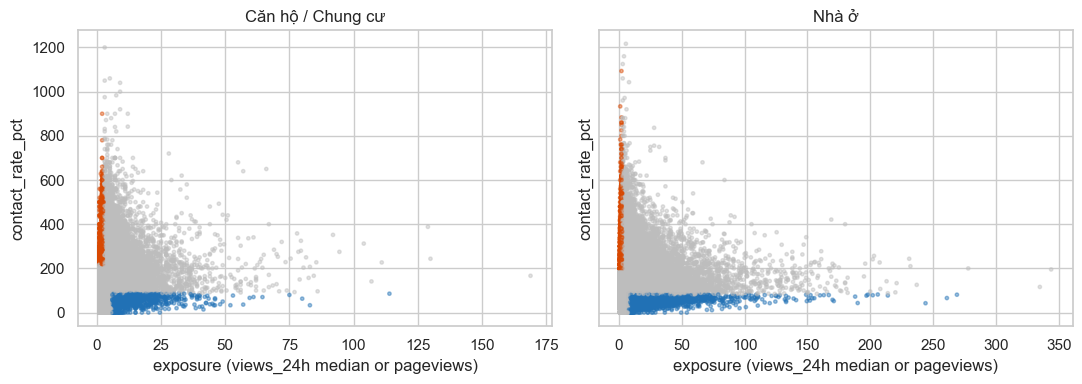

In [12]:
health = listing_feats.copy()
health["exposure"] = health["median_views_24h"].fillna(health["n_pageviews"])
for cat in CATS:
    m = health["category"] == cat
    health.loc[m, "contact_pct_rank"] = health.loc[m, "contact_rate_pct"].rank(pct=True)
    health.loc[m, "exposure_pct_rank"] = health.loc[m, "exposure"].rank(pct=True)

health["health_segment"] = "normal"
health.loc[
    (health["contact_pct_rank"] >= 0.75) & (health["exposure_pct_rank"] <= 0.35),
    "health_segment",
] = "high_quality_underexposed"
health.loc[
    (health["contact_pct_rank"] <= 0.25) & (health["exposure_pct_rank"] >= 0.75),
    "health_segment",
] = "oversaturated_low_conversion"

seg = health.groupby(["category", "health_segment"]).size().reset_index(name="n")
display(seg)
health.to_csv(OUT_DIR / "20_marketplace_health_segments.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, cat in zip(axes, CATS):
    sub = health[health["category"] == cat]
    palette = {
        "high_quality_underexposed": "#d94801",
        "oversaturated_low_conversion": "#2171b5",
        "normal": "#bdbdbd",
    }
    ax.scatter(
        sub["exposure"], sub["contact_rate_pct"],
        c=sub["health_segment"].map(palette).fillna("#bdbdbd"), s=6, alpha=0.45,
    )
    ax.set_xlabel("exposure (views_24h median or pageviews)")
    ax.set_ylabel("contact_rate_pct")
    ax.set_title(UI_LABELS[cat])
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_marketplace_health_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

## §8 — Roadmap phase 2 (competition-grade)

| Module | Method | Data |
|--------|--------|------|
| **User embedding** | Item2Vec / SASRec trên chuỗi `item_id` theo `session_id` | `events_enriched` |
| **Listing embedding** | Co-view / co-contact matrix + matrix factorization | events |
| **Lifecycle TS** | DTW / `tslearn` trên chuỗi `views_24h`, `contacts_24h` | `fact_listing_snapshot` |
| **Recsys hook** | Re-rank: boost `high_quality_underexposed`, demote clickbait cluster | clusters + health |
| **Fairness** | Cap exposure theo seller cluster spam | seller clusters |

### Câu chuyện competition

1. **Segment** marketplace bằng behavioral clusters (không README category nhầm).
2. **Explain** từng cluster bằng profile CSV + suggested labels.
3. **Act** — recommendation / ranking thay đổi theo user intent cluster × listing health segment.

File export chính: `outputs/eda_category_1010_1020/clustering/*.csv`